____
# Sensitivity to stain and vorticity


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, 15m_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs,  prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# 15m

In [3]:
comb_list = [dict(drifter_key='nofilter',spectral_key = 'LF', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==15, drop=True)
dff = DSS.to_dataframe().reset_index().set_index('row_number')

/Users/mdemol/code/med_analysis/diagnosis.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
/Users/mdemol/code/med_analysis/diagnosis.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs


nofilter_LF__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


_______
# Visualized

In [4]:
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')[['duacs_relative_vorticity','duacs_strain', 'vorticity', 'sigma_n', 'sigma_s']]
df = pd.concat([dff, dfs], axis=1).dropna()
df['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)


In [5]:
fo = df.f.mean()
df['strain'] = np.sqrt(df.sigma_n**2 + df.sigma_s**2)
df['strain_f'] = df.strain/abs(df.f)#.assign_attrs({'long_name':r'$\sigma/|f|$'})
df['duacs_vorticity_f'] = df.duacs_relative_vorticity#.assign_attrs({'long_name':r'$\zeta/f$'})
df['vorticity_f'] = df.vorticity/df.f#.assign_attrs({'long_name':r'$\zeta/f$'})
df['gamma'] = df.strain**2 - df.vorticity**2

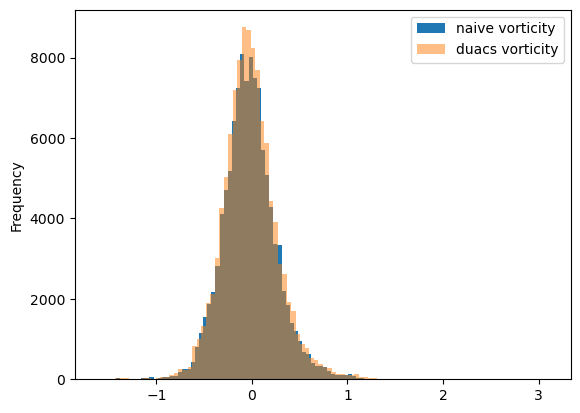

In [6]:
df.vorticity_f.plot.hist(bins=100, label= 'naive vorticity')
df.duacs_vorticity_f.plot.hist(bins=100, label= 'duacs vorticity', alpha=0.5)
plt.legend()

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


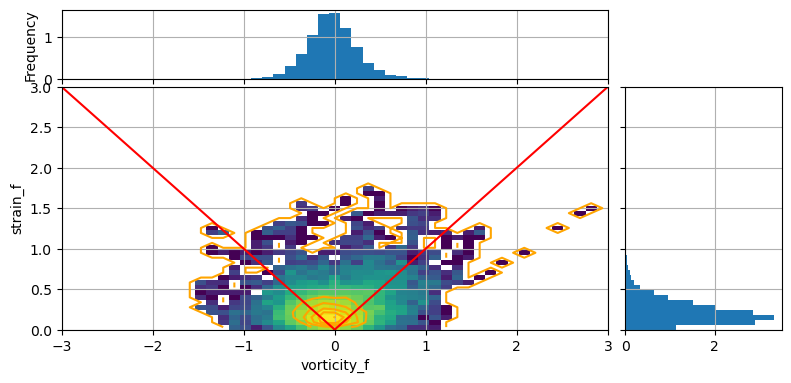

In [7]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    plt.rcParams["axes.edgecolor"] = "k"
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    from matplotlib import colors
    np.log(da).plot(ax=ax, add_colorbar=False)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, xx, color='r')
    #ax.plot(xx, 3/4 * xx, color='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    #fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

    

plot_join_pdfs(df, 'vorticity_f', 'strain_f', binx=np.linspace(-3, 3, 50), biny=np.linspace(0, 3,50))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


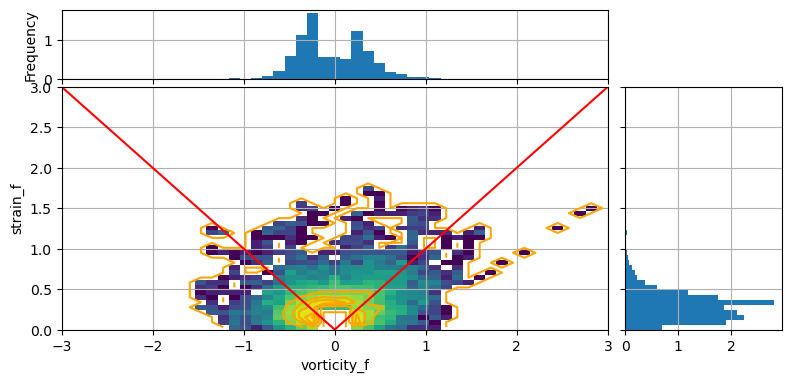

In [8]:
df0 = df.copy()
df = df0[~((abs(df0.vorticity_f)<0.2)&(df0.strain_f<0.3))]
plt.rcParams["axes.edgecolor"] = "k"
plot_join_pdfs(df, 'vorticity_f', 'strain_f', binx=np.linspace(-3, 3, 50), biny=np.linspace(0, 3,50))

____
# Closure

In [9]:
DSz = {'AVD': df[(df.vorticity<0) & (df.strain<abs(df.vorticity))].to_xarray(), 
       'CVD': df[(df.vorticity>0) & (df.strain<abs(df.vorticity))].to_xarray(), 
       'SD': df[df.strain>=abs(df.vorticity)].to_xarray()}

In [10]:
D = []
# Closure figs
for k in DSz:
    print(DSz[k].dims['row_number'])
    D.append(compute_mean_square(DSz[k])/U2)
dsz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfz =dsz.to_dataframe()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/784813993.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz[k].dims['row_number'])
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/784813993.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz[k].dims['row_number'])


20824
14071
25167


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/784813993.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSz[k].dims['row_number'])


2.9120831472805615
3.1010275086822214
4.001964816799971
4.283131302475628
2.8111093024493696
2.906645318096306
3.8811695001242508
3.898856877688425
2.9891997035059448
3.056098571705505
4.796357656530045
4.9667733074998415


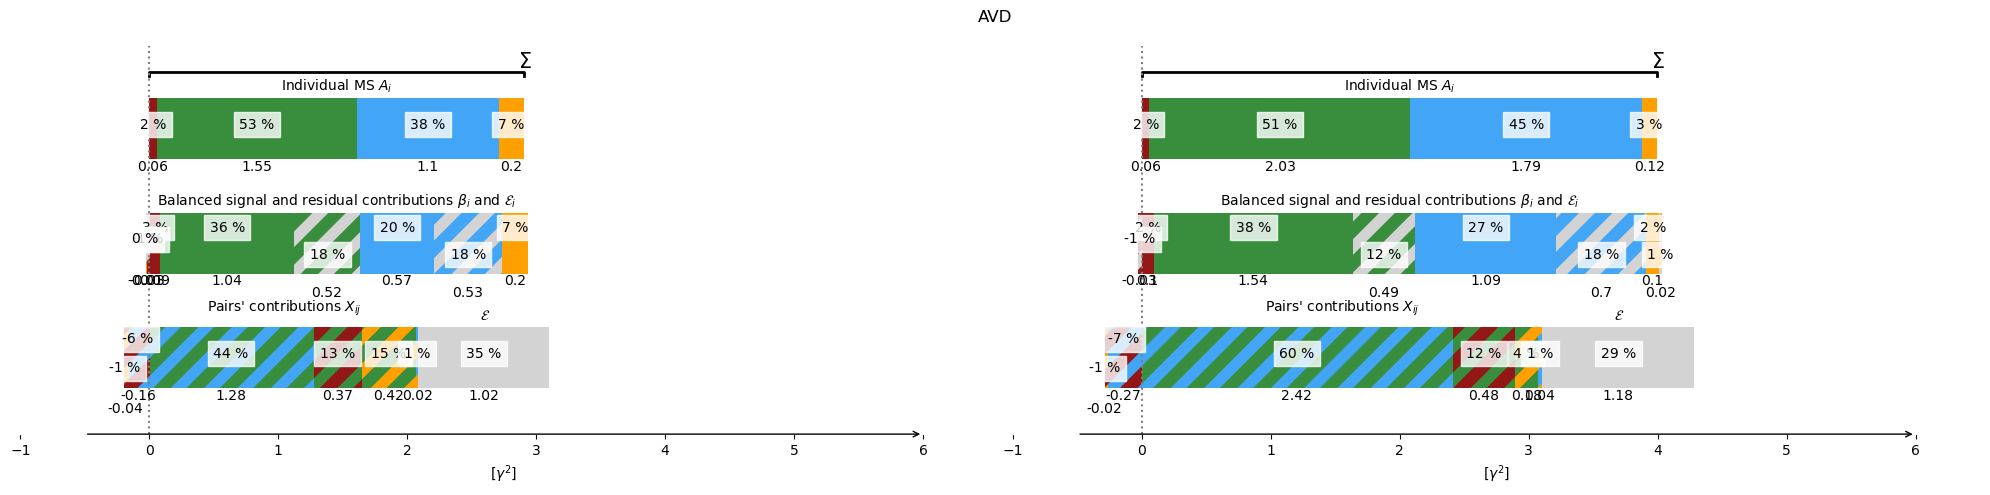

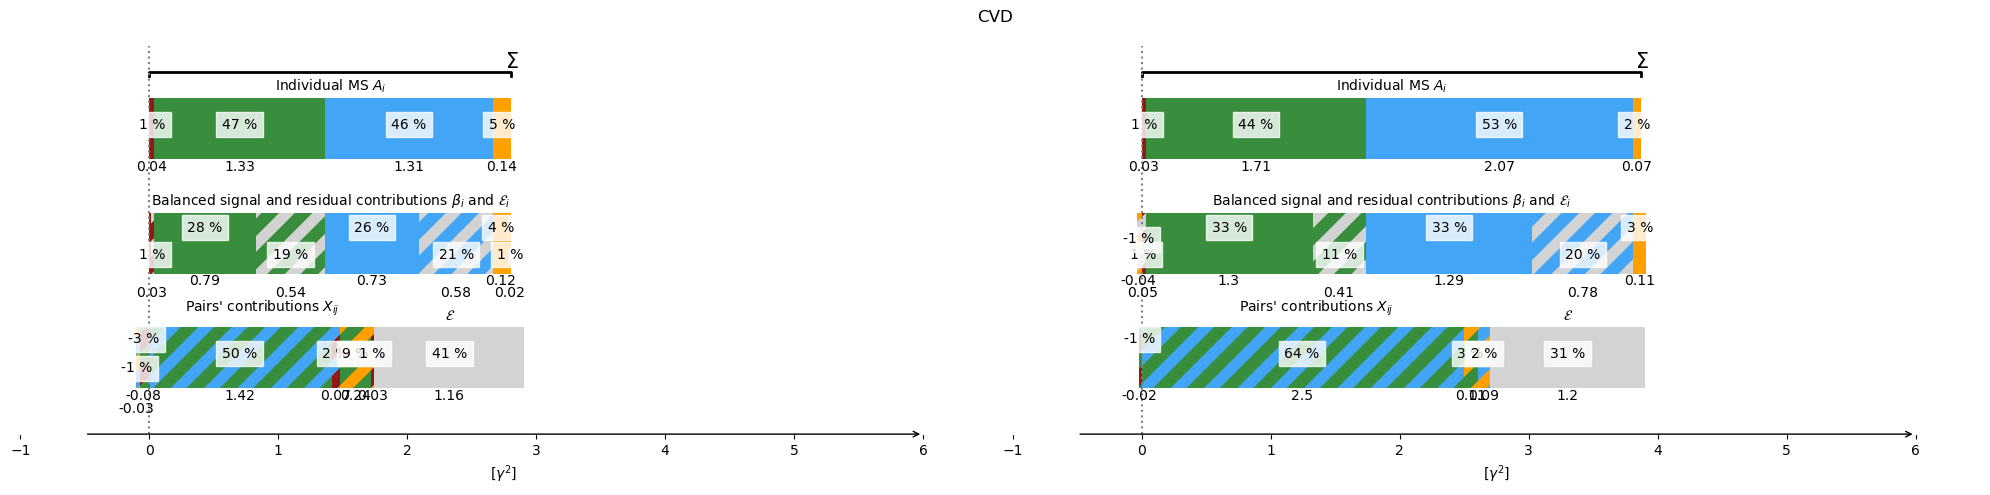

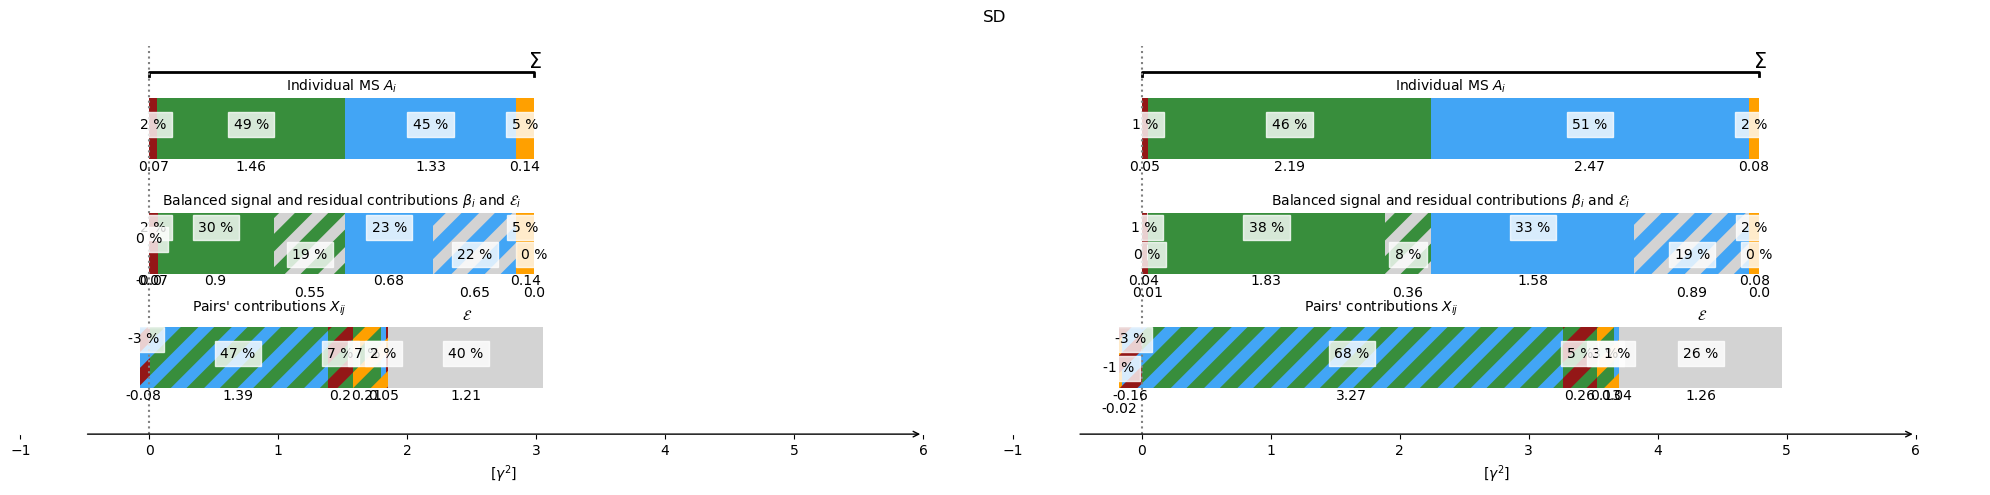

In [11]:
for d in dfz.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(dfz.loc[d], axs[0], dir='e', xlim=[-1, 6])
    synthetic_figure(dfz.loc[d], axs[1], dir='n', xlim=[-1, 6])
    fig.suptitle(d)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + d + '.png'))


6.914047964080533
7.39415881115785
6.692278802573621
6.781192548843543
7.785557360035991
8.019330368110905


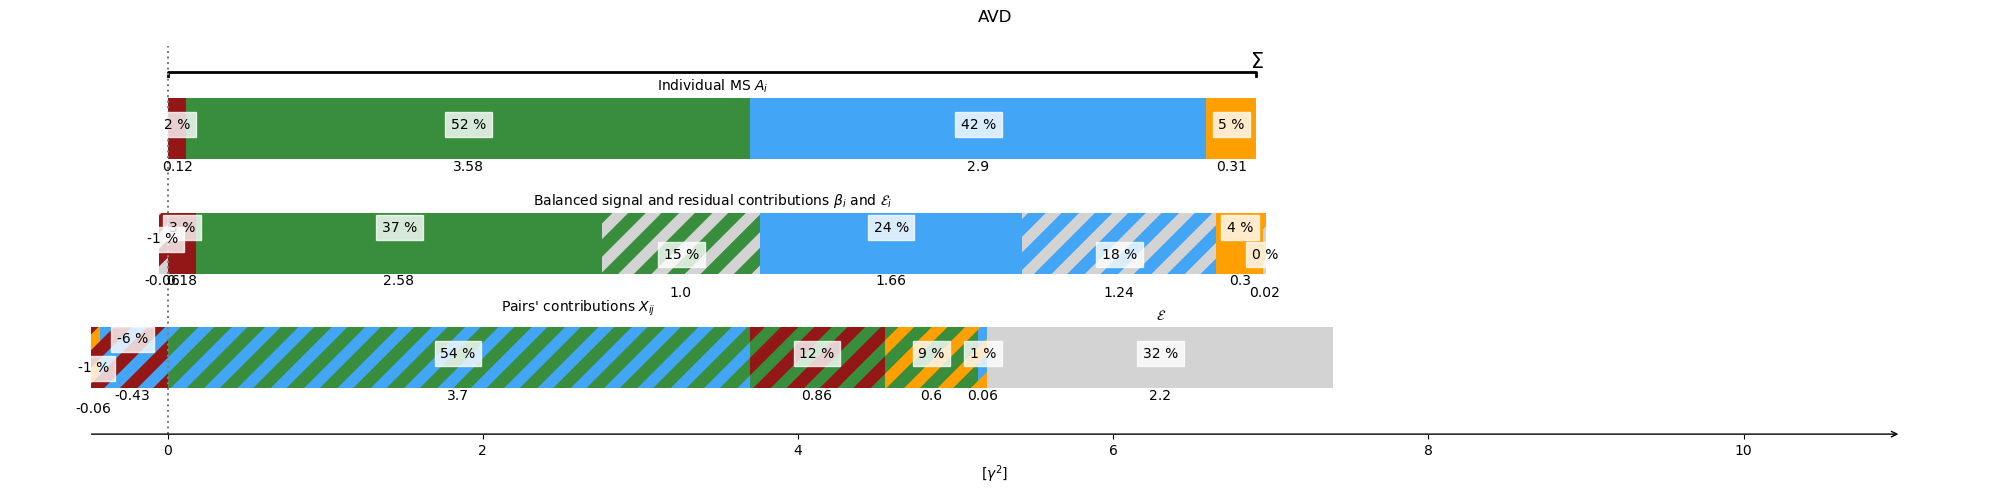

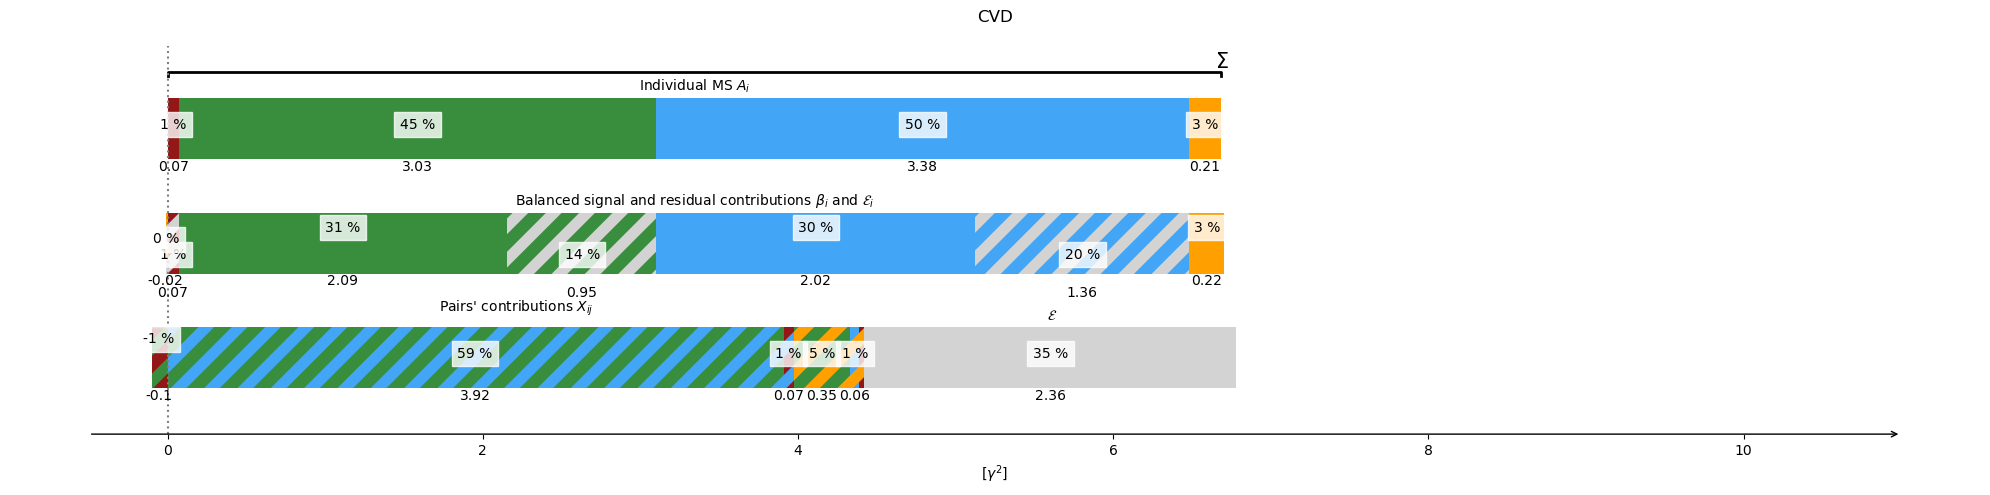

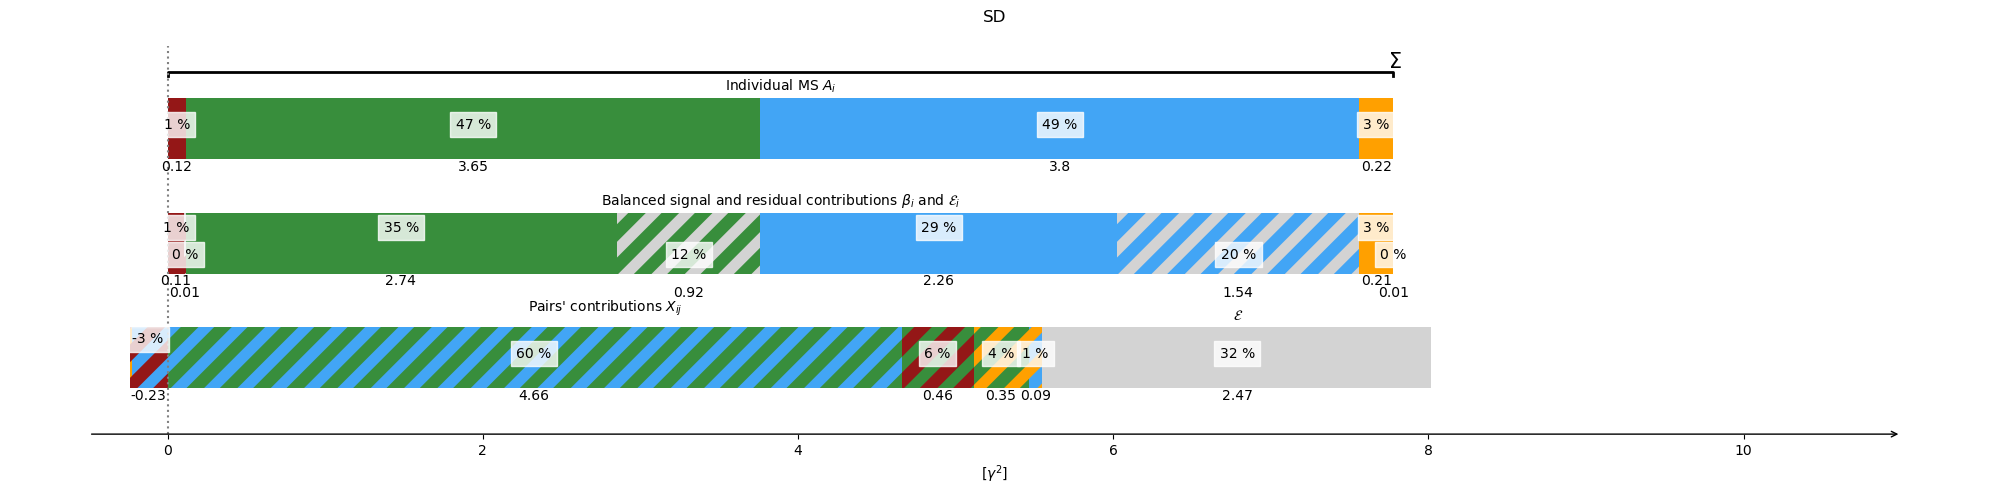

In [12]:
for d in dfz.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(20,5), frameon=False)
    synthetic_figure(dfz.loc[d], ax, dir='', xlim=[-1, 11])
    fig.suptitle(d)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', 'BF15m_' + d + '.png'))


_________
# Where ?

In [13]:
Dll = []
dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)
for k in DSz:
    dfl = DSz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_mean_square_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), bootstrap = False, vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

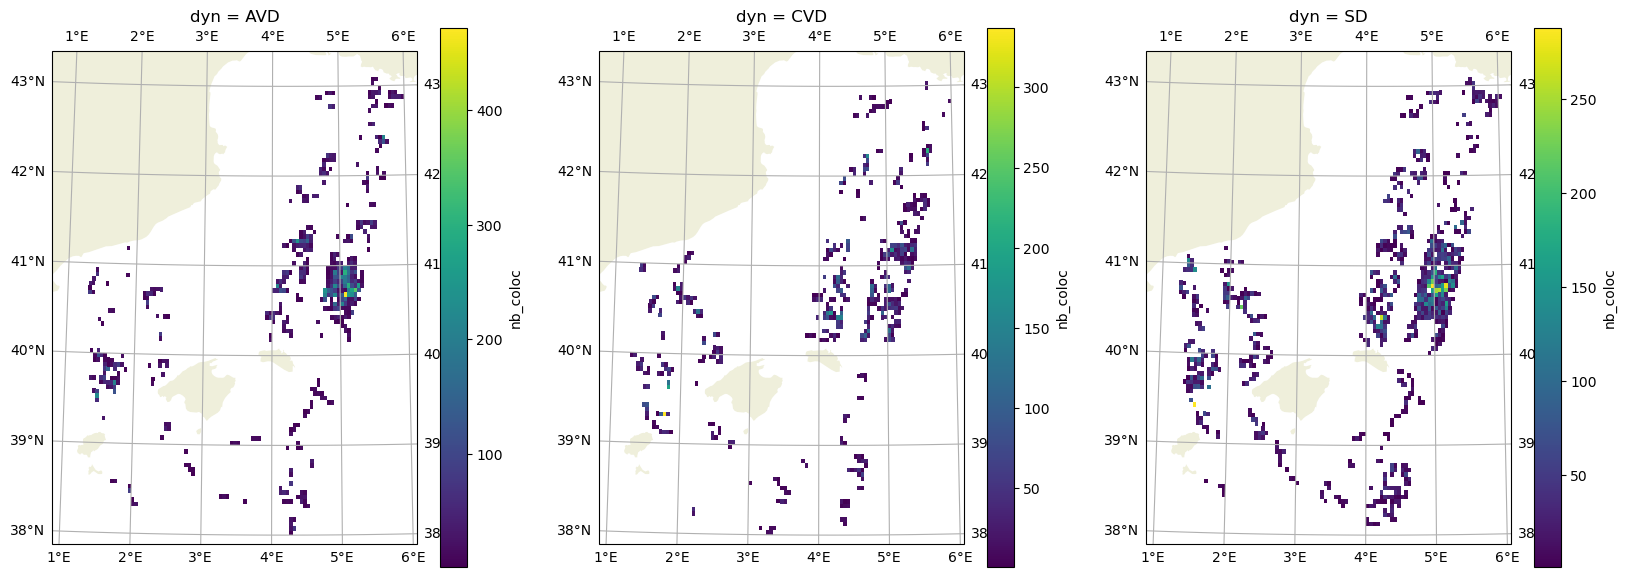

In [14]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.plot(ax=ax, transform=crs)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

In [15]:
dll

<xarray.Dataset> Size: 18MB
Dimensions:        (dyn: 3, latitude_cut: 109, longitude_cut: 103)
Coordinates:
  * latitude_cut   (latitude_cut) float64 872B 37.92 37.97 38.02 ... 43.27 43.32
  * longitude_cut  (longitude_cut) float64 824B 0.925 0.975 ... 5.975 6.025
  * dyn            (dyn) object 24B 'AVD' 'CVD' 'SD'
Data variables: (12/67)
    ACCe           (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    CORe           (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    GGDe           (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    WDe            (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    Se             (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    sigmae         (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    ...             ...
    X_acc_wd       (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    X_cor_ggd      (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    X_cor_wd       (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    X_ggd_wd       (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    D_cyclo        (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan
    D_anticyclo    (dyn, latitude_cut, longitude_cut) float64 269kB nan ... nan

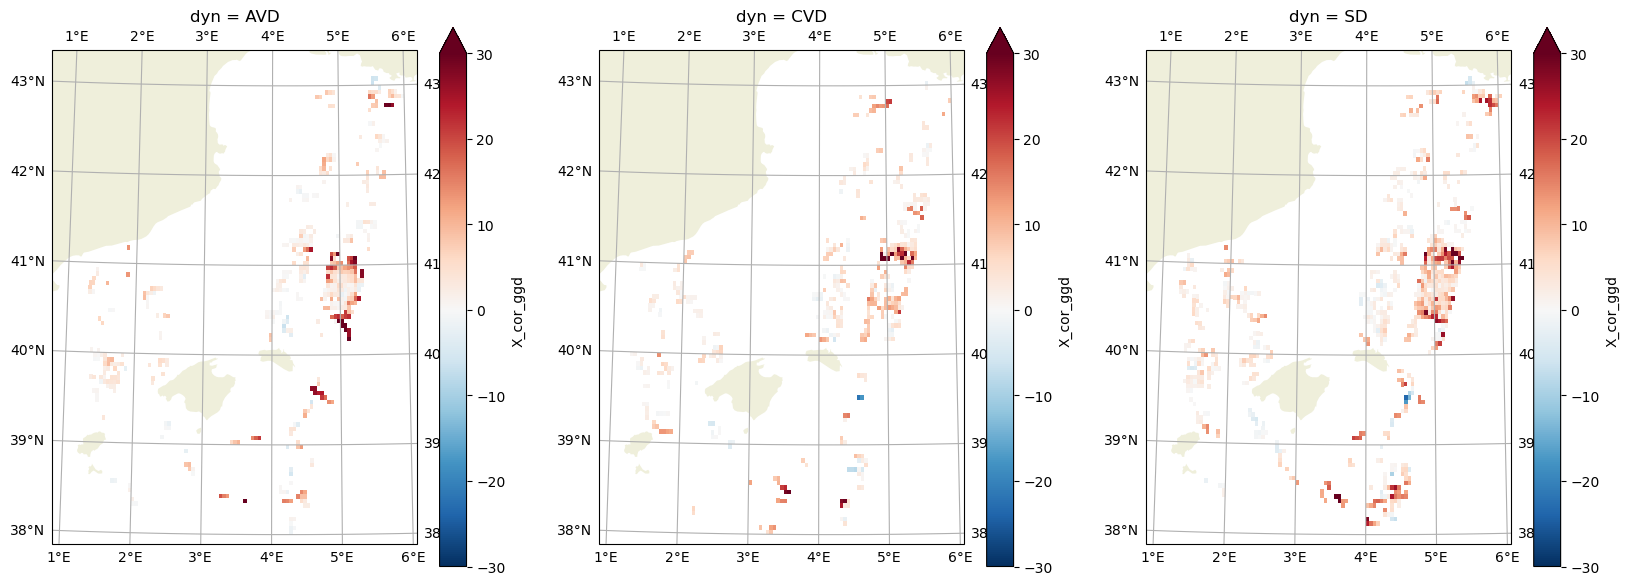

In [16]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).X_cor_ggd.plot(ax=ax, transform=crs, vmax=30)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

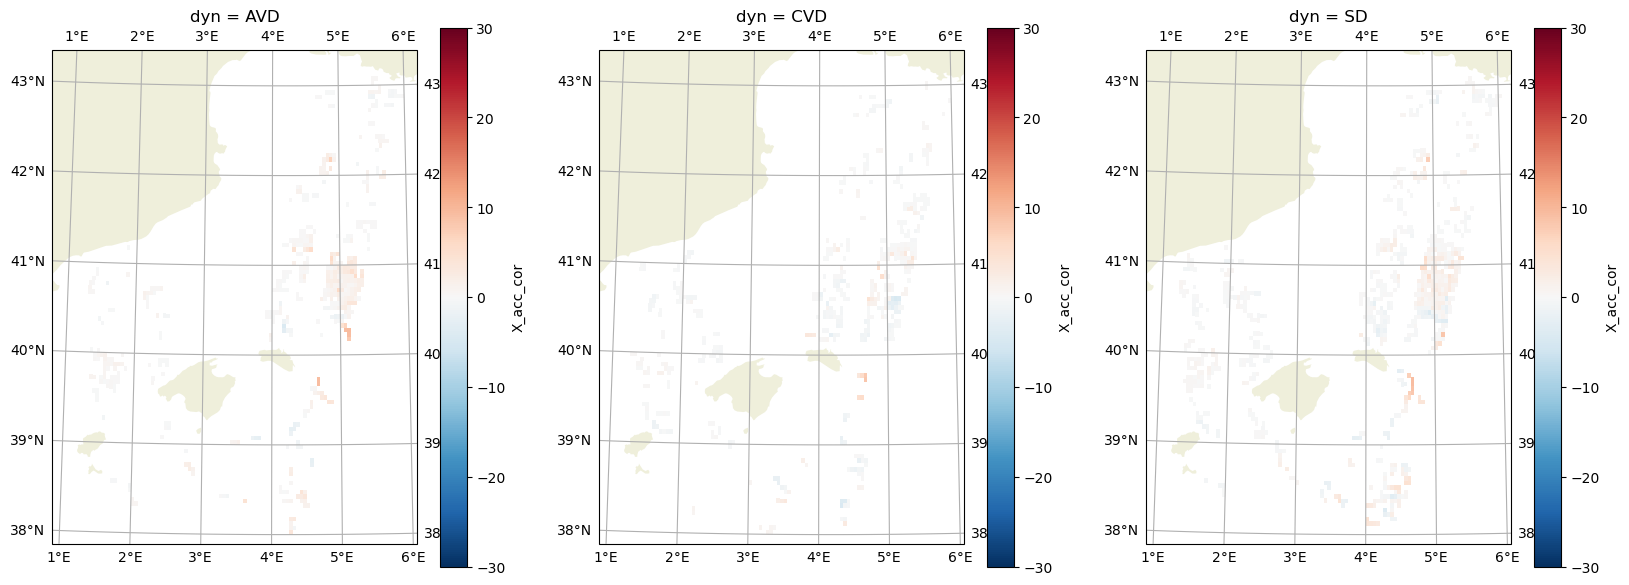

In [17]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).X_acc_cor.plot(ax=ax, transform=crs, vmax=30)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

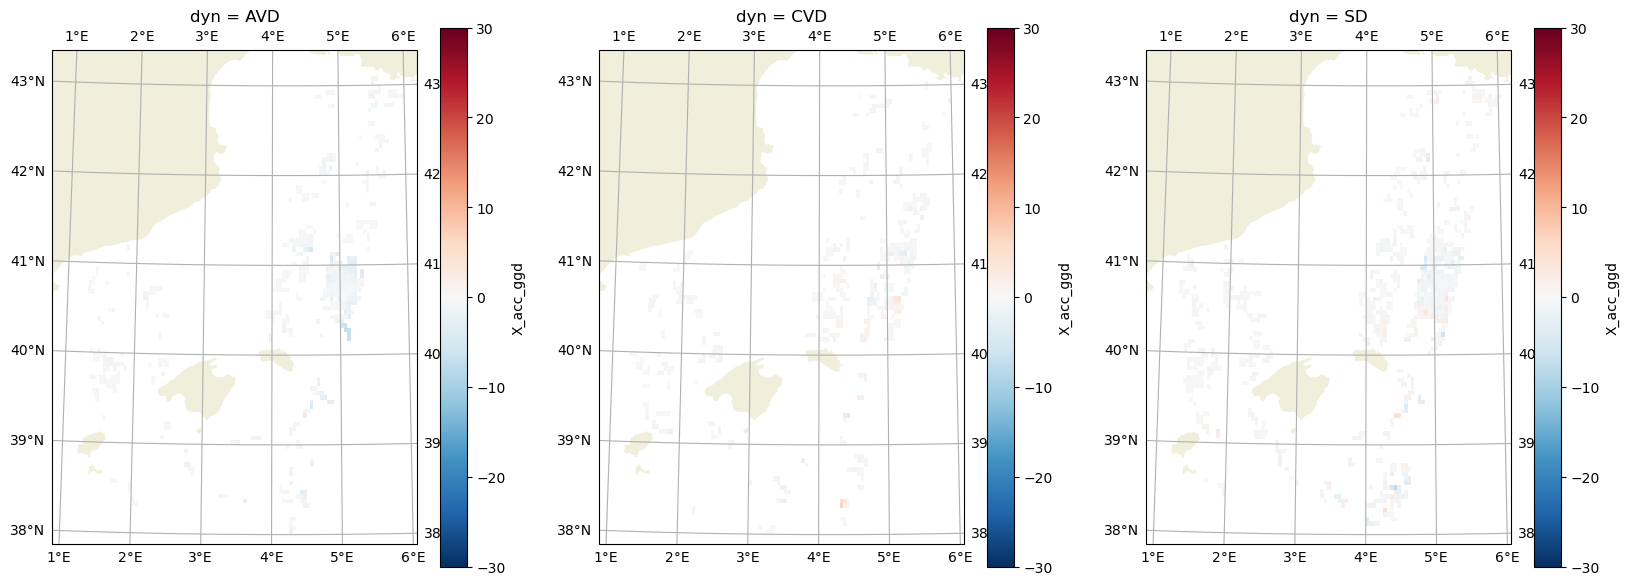

In [18]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).X_acc_ggd.plot(ax=ax, transform=crs, vmax=30)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

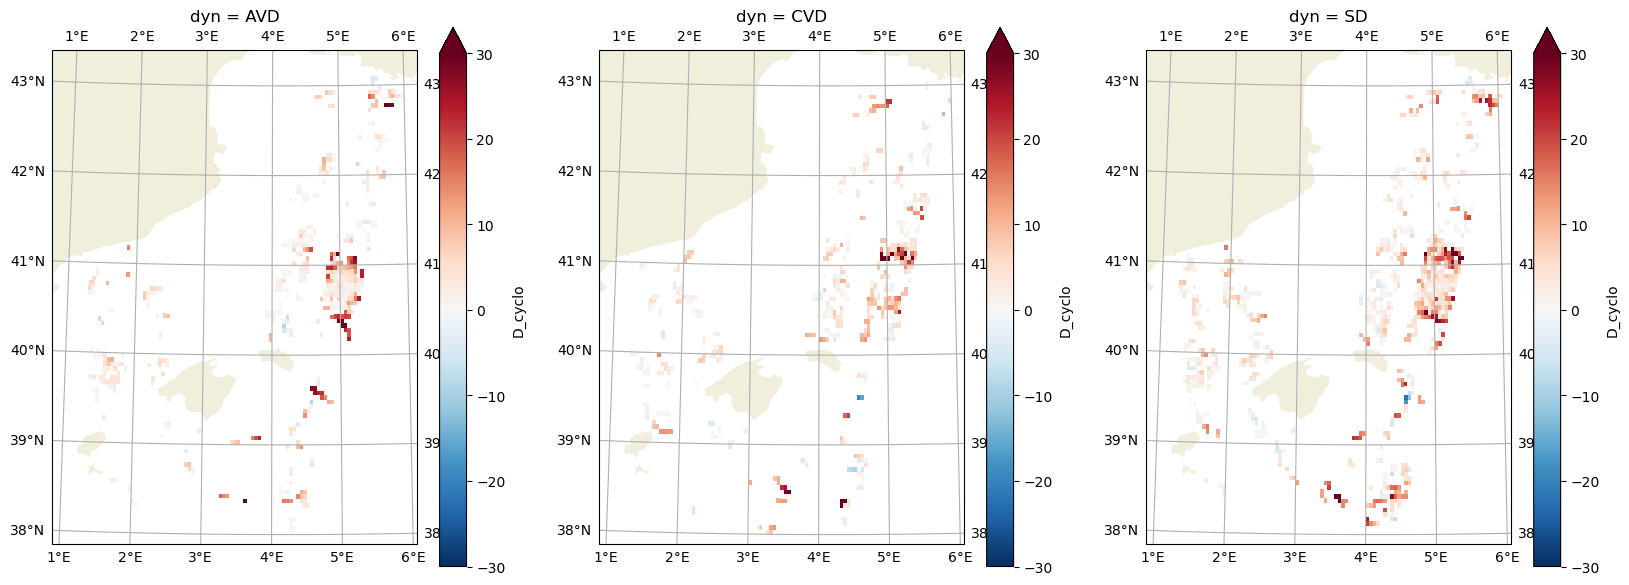

In [19]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).D_cyclo.plot(ax=ax, transform=crs, vmax=30)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

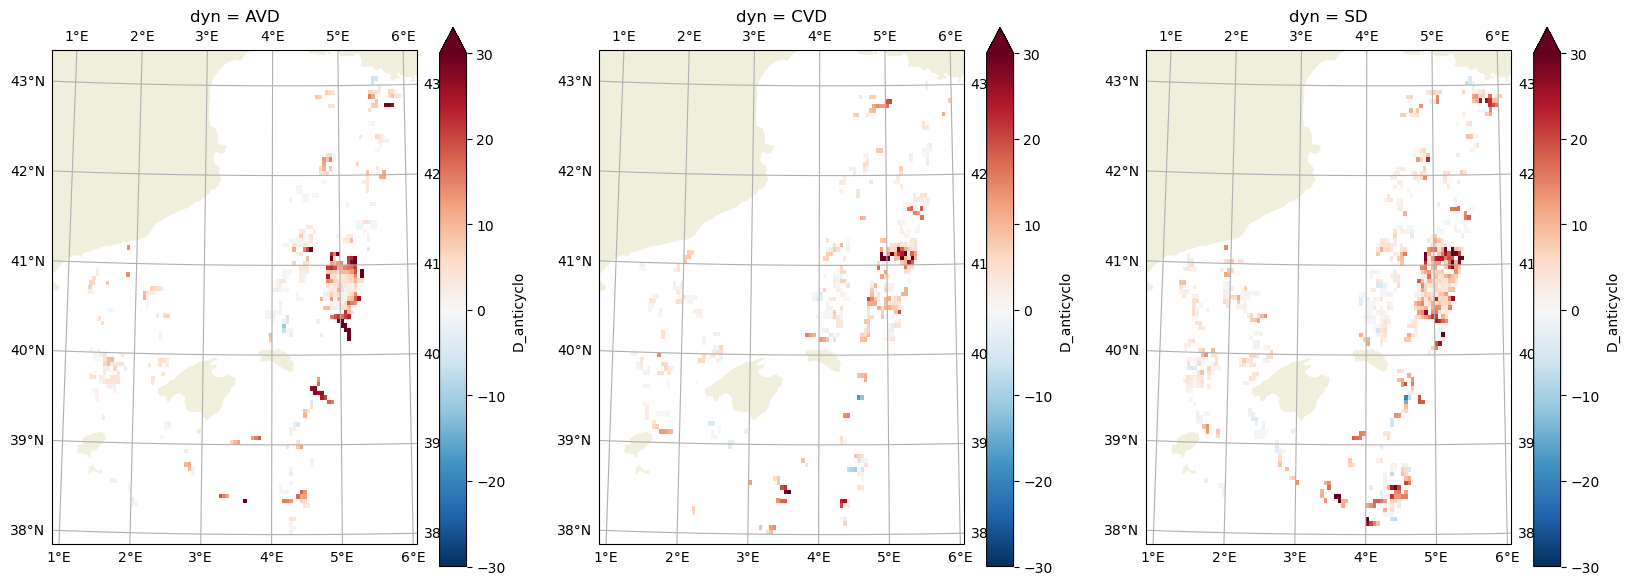

In [20]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).D_anticyclo.plot(ax=ax, transform=crs, vmax=30)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

____
# BIOSWOT-SWOT anticyclonic eddy

In [25]:
dfa = df0[(df0.latitude>40)&(df0.latitude<41.3)&(df0.longitude>4.5)&(df0.longitude<5.5)]

In [26]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)

dfa['longitude_cut']= pd.cut(dfa['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
dfa['latitude_cut']= pd.cut(dfa['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
#dsa = compute_mean_square_groupby(dfa, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), bootstrap = False, vars_errors=None))
dsam = dfa[['longitude_cut','latitude_cut','strain', 'strain_f', 'duacs_vorticity_f','vorticity_f', 'gamma']].groupby(['longitude_cut','latitude_cut' ], observed=False).mean().to_xarray()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/963291271.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfa['longitude_cut']= pd.cut(dfa['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/963291271.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfa['latitude_cut']= pd.cut(dfa['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)


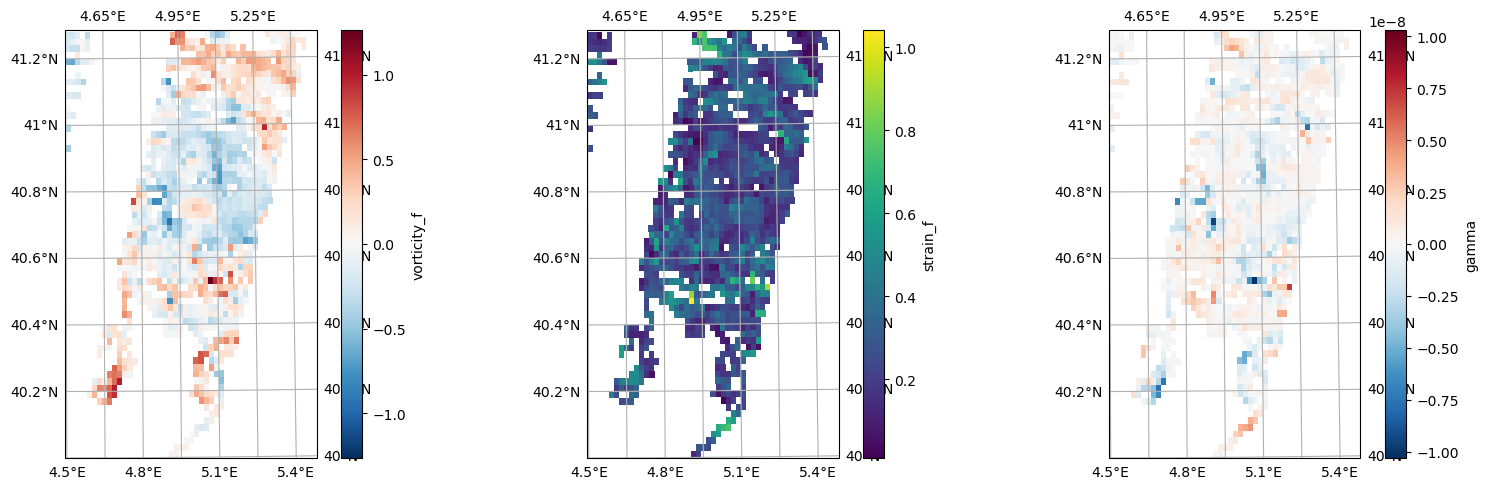

In [27]:
plt.rcParams["axes.edgecolor"] = "k"
fig = plt.figure(figsize=(16, 5))
ax = fig.add_subplot(131, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
dsam.vorticity_f.plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)

ax = fig.add_subplot(132, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
dsam.strain_f.plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)

ax = fig.add_subplot(133, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
dsam.gamma.plot(ax=ax,x='longitude_cut', y='latitude_cut', transform=crs)
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)

fig.tight_layout()

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/core/computation.py:821: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


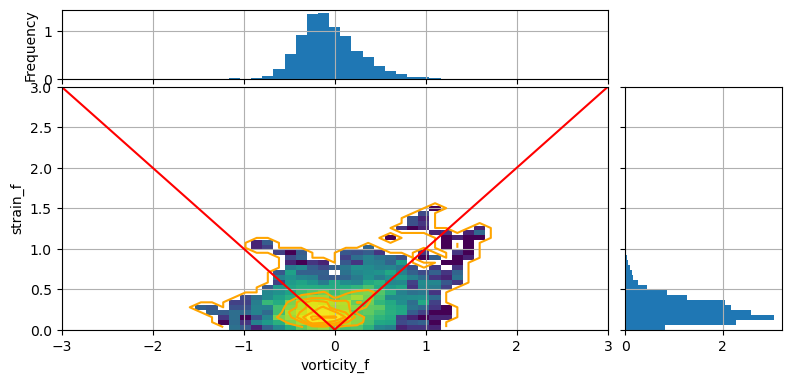

In [28]:
plot_join_pdfs(dfa, 'vorticity_f', 'strain_f', binx=np.linspace(-3, 3, 50), biny=np.linspace(0, 3,50))

In [29]:
DSaz = {'AVD': dfa[(dfa.vorticity<0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'CVD': dfa[(dfa.vorticity>0) & (dfa.strain<abs(dfa.vorticity))].to_xarray(), 
       'SD': dfa[dfa.strain>=abs(dfa.vorticity)].to_xarray()}

In [30]:
D = []
# Closure figs
for k in DSaz:
    print(DSaz[k].dims['row_number'])
    D.append(compute_mean_square(DSaz[k])/U2)
dsaz = xr.concat(D, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))
dfaz =dsaz.to_dataframe()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])


12701
5669
20771


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_9002/1806971662.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(DSaz[k].dims['row_number'])


In [33]:
Dll = []
dl=0.02
lonbins = np.arange(4.5, 5.5, dl)
latbins = np.arange(40, 41.3, dl)
for k in DSaz:
    dfl = DSaz[k].to_dataframe()
    dfl['longitude_cut']= pd.cut(dfl['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    dfl['latitude_cut']= pd.cut(dfl['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    Dll.append(compute_mean_square_groupby(dfl, groupby = ['latitude_cut', 'longitude_cut'], dirname = ('e', 'n'), bootstrap = False, vars_errors=None))

dll = xr.concat(Dll, pd.Index(['AVD', 'CVD', 'SD'], name='dyn'))

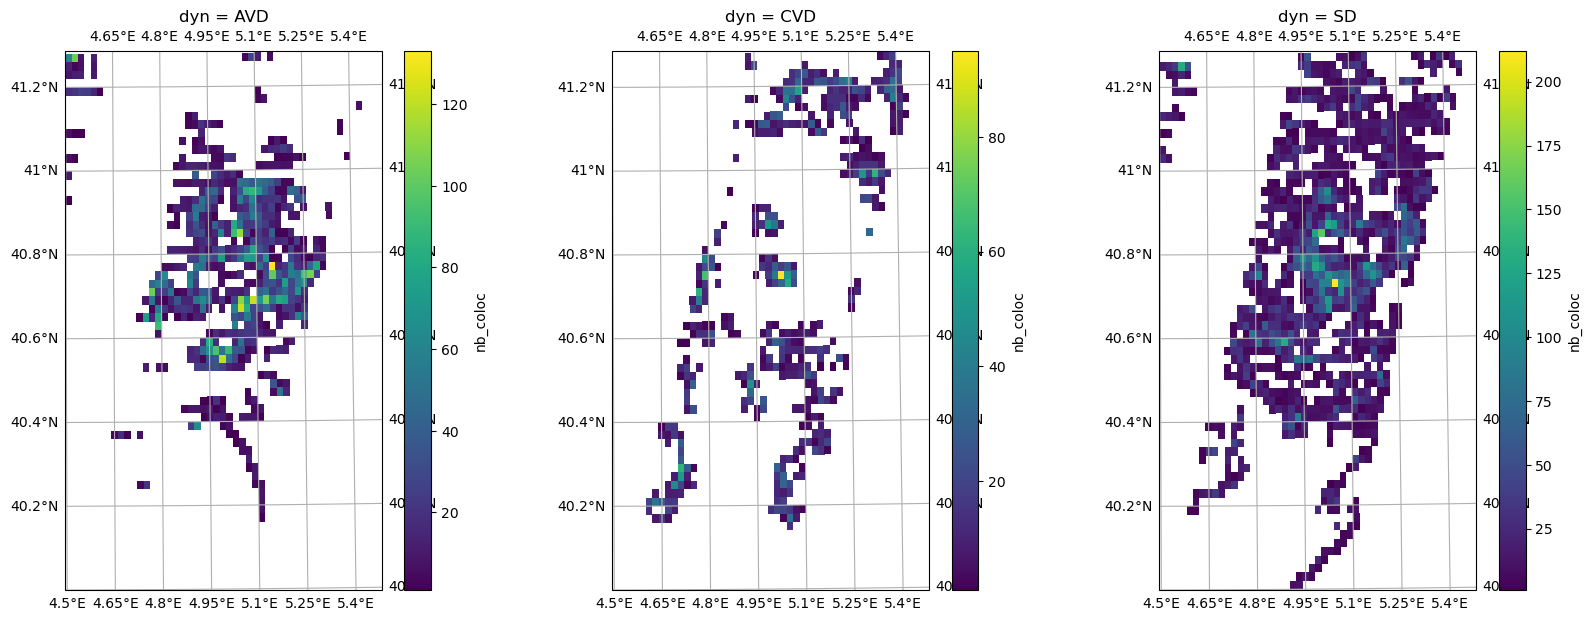

In [34]:
fig = plt.figure(figsize=(20,7))
plt.rcParams["axes.edgecolor"] = "k"
i=0
for d in dll.dyn.values:
    ax = fig.add_subplot(1, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    dll.sel(dyn=d).where(dll.sel(dyn=d).nb_coloc!=0).nb_coloc.plot(ax=ax, transform=crs)
    i+=1
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)

8.05710762731054
8.864092878190338
9.547173091754573
9.552382556097317
9.31467841714653
9.83312871840649


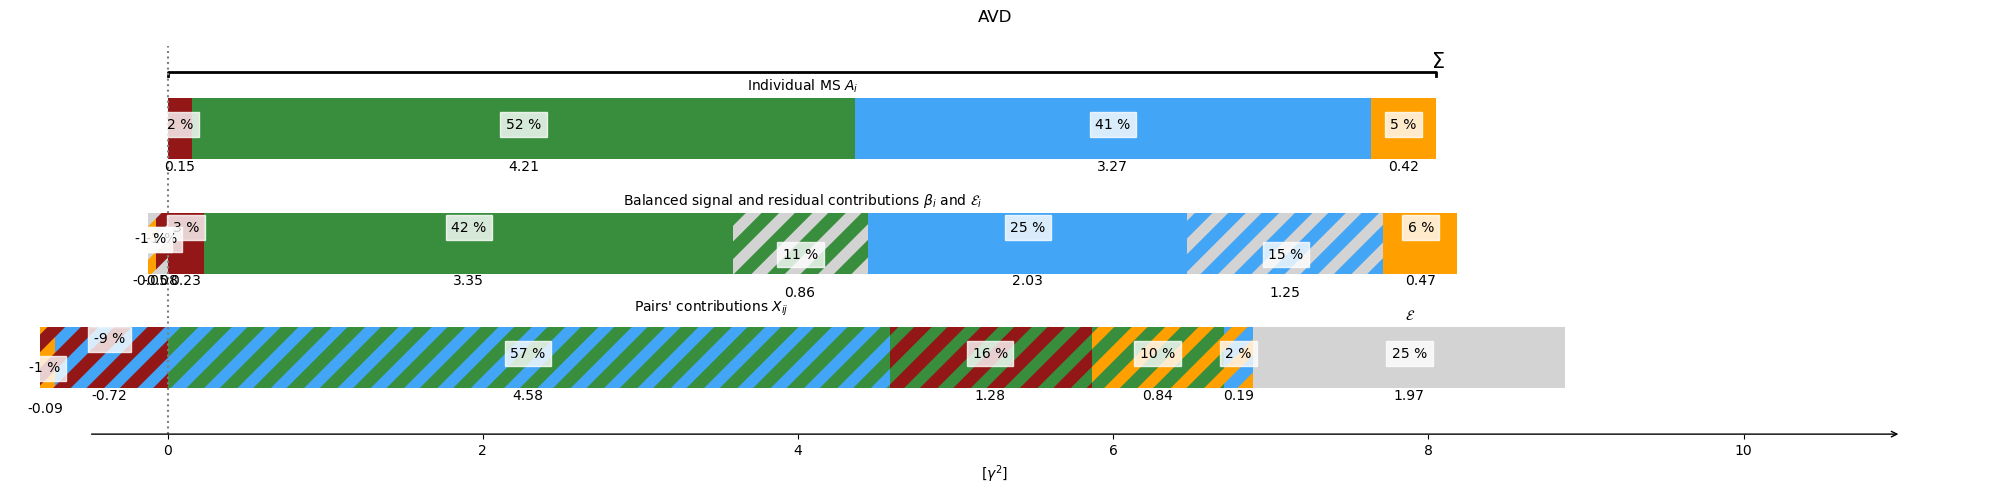

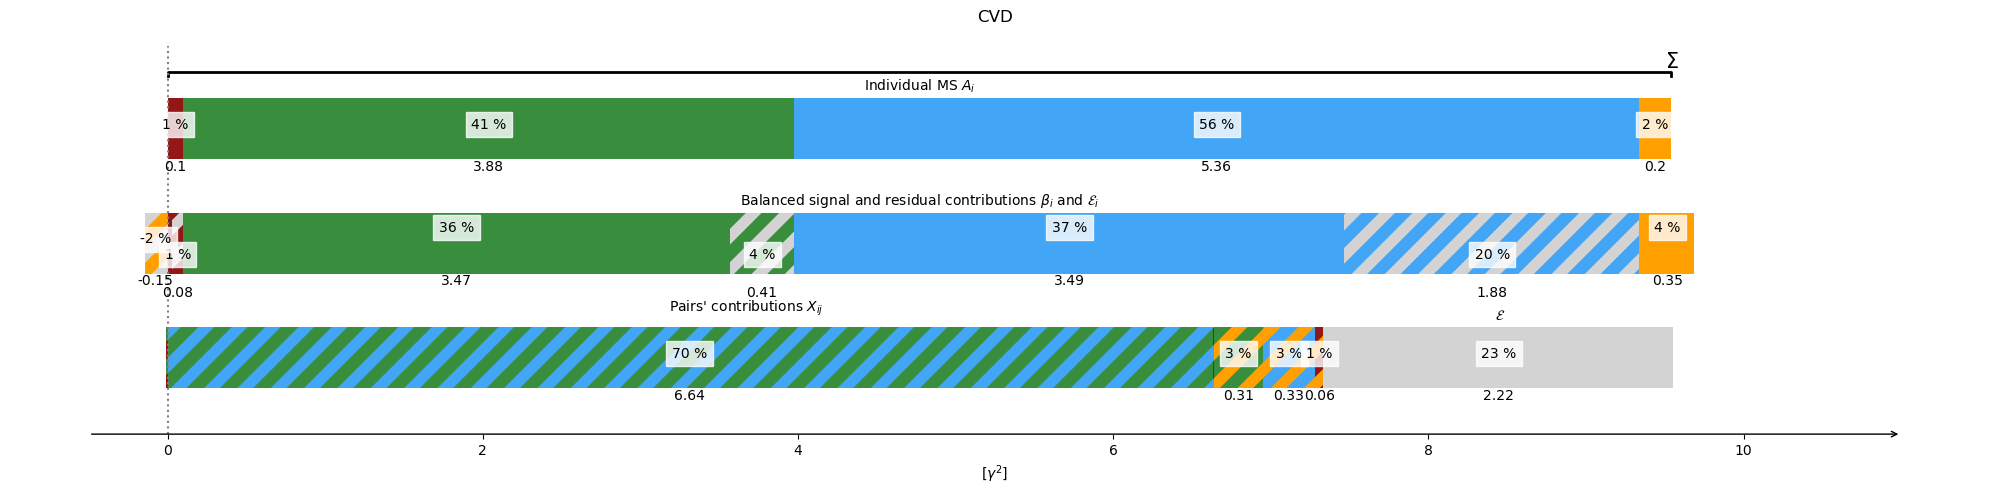

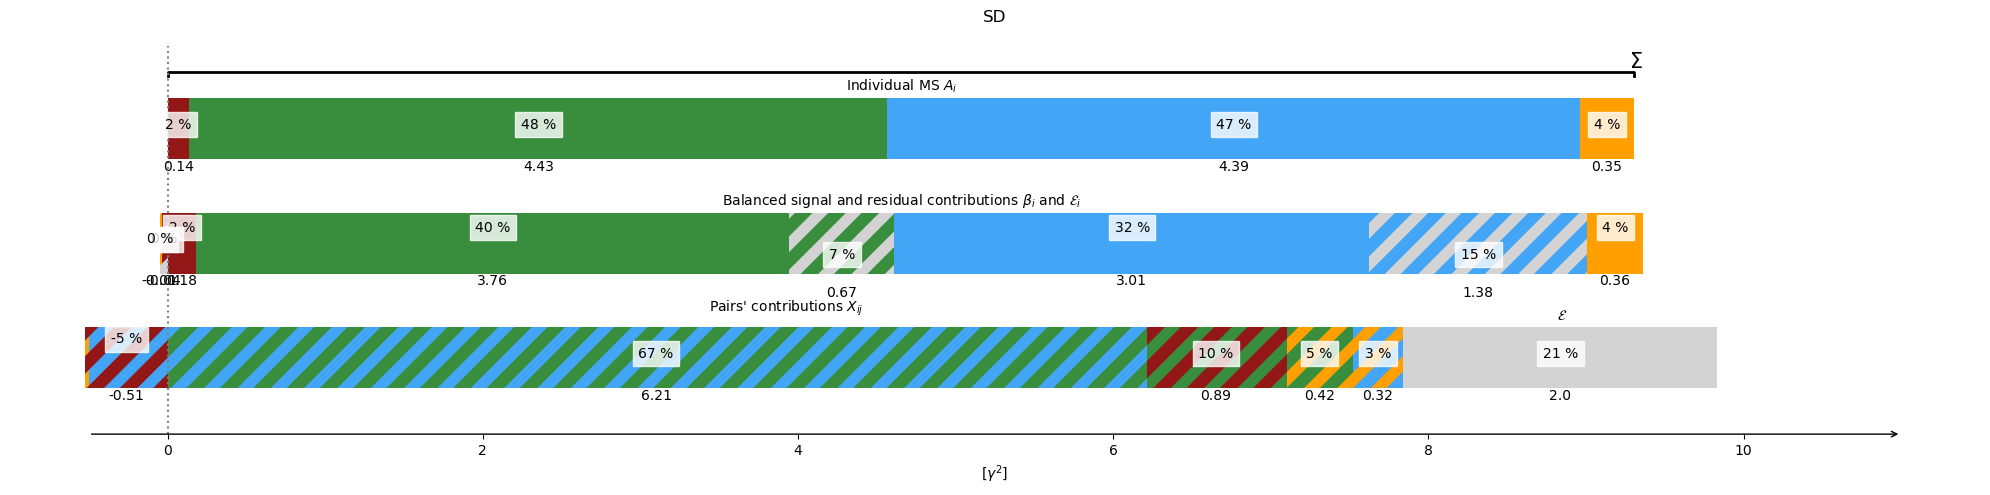

In [35]:
for d in dfaz.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(20,5), frameon=False)
    synthetic_figure(dfaz.loc[d], ax, dir='', xlim=[-1, 11])
    fig.suptitle(d)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', 'BF15m_' + d + '.png'))
